## Chain Using LangGraph

We can build a simple chain using LangGraph that uses 4 important concepts :

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

### How to use Chat Messages as our graph state

#### Messages

We can use messages which can be used to capture different roles within a conversation. LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage. These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g. often populated by model provider for AIMessages)

In [2]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

messages = [AIMessage(content=f"Please tell me how can I help you?", name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding",name="Karan"))
messages.append(AIMessage(content=f"Which programming language do you want to learn?", name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn Python programming language",name="Karan"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help you?
================================ Human Message =================================
Name: Karan

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language do you want to learn?
================================ Human Message =================================
Name: Karan

I want to learn Python programming language


### Chat Models

We can use the sequence of messages as input with the chatmodels using LLM's and OPENAI

In [3]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.3-70b-versatile")
llm.invoke(messages)

c:\Users\Karan\Desktop\agentic-ai-langchain-langgraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Python is a great language to start with, especially for beginners. It\'s easy to learn, versatile, and has a wide range of applications.\n\nTo get started, here are some steps you can follow:\n\n1. **Install Python**: First, you need to install Python on your computer. You can download the latest version from the official Python website: <https://www.python.org/downloads/>.\n2. **Choose a Text Editor or IDE**: A text editor or IDE (Integrated Development Environment) is where you\'ll write your Python code. Some popular choices include:\n\t* PyCharm\n\t* Visual Studio Code (VS Code)\n\t* Sublime Text\n\t* Atom\n\t* IDLE (comes bundled with Python)\n3. **Learn the Basics**: Start with basic syntax and data types in Python. You can find many resources online, such as:\n\t* Codecademy\'s Python course\n\t* Python.org (official tutorials)\n\t* W3Schools\' Python tutorial\n\t* YouTube tutorials (e.g., Corey Schafer\'s Python Tutorials)\n4. **Practice**: Practice is key t

## Tools

Tools can be integrated with the LLM models to interact with external systems. External system can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the natural language input and this will return an output that matches the tool's schema.

In [4]:
def add(a:int, b:int)-> int:
    """ Add a and b
    Args:
        a(int): first int
        b(int): second int

    Returns:
        int
    """
    return a + b

In [5]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021359132A50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021359133770>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
### Binding tool with LLM

llm_with_tools = llm.bind_tools([add])

tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2",name="Karan")])


In [8]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'jv3111h18',
  'type': 'tool_call'}]

#### Reducers

Each node will return a new value for our state key messages.

But, this value will override the prior message value.

We want to append messages to our messages state key.

We can use reducer function to address this.

```Reducers``` allow us to specify how state updates are performed

If no reducer function is specified, then it is assumed that updates to the key should override it.

But, to append messages, we can use the pre-built ```add_messages``` reducer.

This ensures that any messages are appended to the existing list of messages.

We need to annotate our messages key with the ```add_messages``` reducer function as metadata.

### Using Messages as State

In [9]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

#### Reducers with add_messages

In [10]:
initial_messages = [AIMessage(content=f"Please tell me how can I help you?", name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding",name="Karan"))
initial_messages

[AIMessage(content='Please tell me how can I help you?', additional_kwargs={}, response_metadata={}, name='LLMModel'),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Karan')]

In [11]:
ai_message = AIMessage(content=f"Which programming language do you want to learn?", name="LLMModel")
ai_message

AIMessage(content='Which programming language do you want to learn?', additional_kwargs={}, response_metadata={}, name='LLMModel')

In [12]:
### Reducers add_messages is used to append instead of overriding.
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tell me how can I help you?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='cfa2048f-e24f-4843-9da6-0f3487888fd4'),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Karan', id='7523161d-6bc7-48bb-8f57-2863c34b4f2b'),
 AIMessage(content='Which programming language do you want to learn?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='b5507b67-8dea-4872-9737-ae68ceedd4c7')]

In [13]:
def llm_tool(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {
        "messages": [response]
    }


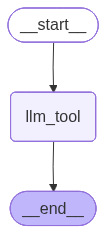

In [14]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)
builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
from langchain_core.messages import HumanMessage

result = graph.invoke({
    "messages": [HumanMessage(content="What is 2+3")]
})

for m in result["messages"]:
    m.pretty_print()


================================ Human Message =================================

What is 2+3
================================== Ai Message ==================================
Tool Calls:
  add (s2q34d3q5)
 Call ID: s2q34d3q5
  Args:
    a: 2
    b: 3


In [16]:
tools=[add]

In [22]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)

# Nodes
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "llm_tool")

builder.add_conditional_edges(
    "llm_tool",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END,
    },
)

# 🔁 THIS IS THE CRITICAL LINE
builder.add_edge("tools", "llm_tool")

graph = builder.compile()


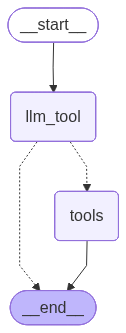

In [23]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [26]:
from langchain_core.messages import HumanMessage

result = graph.invoke({
    "messages": [HumanMessage(content="What is 9+82")]
})

for m in result["messages"]:
    m.pretty_print()


================================ Human Message =================================

What is 9+82
================================== Ai Message ==================================
Tool Calls:
  add (0dv1rdvnd)
 Call ID: 0dv1rdvnd
  Args:
    a: 9
    b: 82
================================= Tool Message =================================
Name: add

91
================================== Ai Message ==================================

The answer is 91.
